# ATCNet vs Mini-ATCNet — Accuracy / Training Speed / Inference Speed, BCI Competition IV-2a

**Application context**: assistive BCI systems for motor control (e.g. for users who cannot execute a
movement but can still generate the corresponding motor-imagery brain activity) need to decode EEG into
control commands in real time, often on modest or embedded hardware near the user rather than a full GPU
workstation. That latency/footprint constraint is the actual motivation for building a lightweight variant,
**Mini-ATCNet**, rather than always deploying the full model — but a deployment claim like that needs to be
backed by a measured trade-off, not just a parameter count. This notebook runs **both** the full architecture
and the lightweight one, side by side, under an identical protocol, and reports accuracy alongside wall-clock
training and inference time for each.

**What "ATCNet" is, precisely**: [ATCNet](https://github.com/Altaheri/EEG-ATCNet) (Altaheri, Muhammad, Alsulaiman —
*IEEE Transactions on Industrial Informatics*, 2023, [10.1109/TII.2022.3197419](https://doi.org/10.1109/TII.2022.3197419))
is a real, published, widely-cited (600+) architecture that reports 81.10% accuracy on BCI IV-2a with 113,732
parameters (official numbers, from the repository's own README, measured on an Nvidia GTX 1080 Ti). The
"full" configuration below reimplements it directly from the official `models.py` / `attention_models.py`
with the paper's own default hyperparameters.

**What "Mini-ATCNet" is**: **not** a name from the literature — there is no published paper by that name. It
is *our own* lightweight variant of ATCNet's three core blocks (Convolutional block, Attention block,
Temporal Convolutional block), built by deliberately shrinking every major hyperparameter. Every deviation
from the original is listed explicitly in Section 3 below.

**Evaluation protocol**: trial-level epoching (no overlapping-window leakage) and subject-dependent 5-fold
cross-validation, evaluated per subject and averaged, run once per configuration (full vs mini).

## 1. Setup

In [1]:
import os, glob, random, pickle, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mne
mne.set_log_level('ERROR')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.regularizers import L2
from tensorflow.keras.constraints import max_norm

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

tf.config.optimizer.set_jit(False)  # XLA JIT recompiles a new graph whenever input shape changes;
# fold test-set sizes vary slightly (288 trials / 5 folds doesn't divide evenly), and across 90
# fold iterations that was causing progressively slower XLA compiles until a 'Very slow compile'
# alarm. Plain TF graph execution (no XLA) is a bit slower per-step but avoids this entirely.
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
DATA_DIR = '/kaggle/input/datasets/meen14052547/bciciv-2a-gdf/BCICIV_2a_gdf'
SAVE_DIR_ROOT = '/kaggle/working/saved_models_atcnet_compare'
os.makedirs(SAVE_DIR_ROOT, exist_ok=True)
SUBJECTS = list(range(1, 10))

EEG_CHS = [
    'EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5',
    'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9',
    'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz',
    'EEG-15', 'EEG-16'
]
N_CHANS = len(EEG_CHS)

LABEL_MAP = {'769': 0, '770': 1, '771': 2, '772': 3}
CLASS_NAMES = ['Left', 'Right', 'Foot', 'Tongue']
N_CLASSES = 4

TMIN, TMAX = 0.0, 4.0
SFREQ_TARGET = 250

# The two configurations under comparison. 'full' uses ATCNet's own published defaults
# (models.py: ATCNet_ function signature); 'mini' is our lightweight variant.
MODEL_CONFIGS = {
    'ATCNet_full': dict(n_windows=5, eegn_F1=16, eegn_D=2, eegn_kernel_size=64, eegn_pool_size=7, eegn_dropout=0.3,
                         tcn_depth=2, tcn_kernel_size=4, tcn_filters=32, tcn_dropout=0.3,
                         mha_key_dim=8, mha_num_heads=2),
    'Mini-ATCNet': dict(n_windows=3, eegn_F1=8, eegn_D=1, eegn_kernel_size=64, eegn_pool_size=7, eegn_dropout=0.3,
                         tcn_depth=1, tcn_kernel_size=4, tcn_filters=16, tcn_dropout=0.3,
                         mha_key_dim=4, mha_num_heads=1),
}

## 2. Trial-level epoching (no-leakage protocol)

Both configurations take **raw band-pass filtered EEG** as input — no CSP or hand-crafted features. The
network's own depthwise convolution (Convolutional block, Section 3) learns spatial filtering directly from
data, the same way EEGNet does.

In [3]:
def load_subject_epochs(subject, session='T'):
    path = os.path.join(DATA_DIR, f'A{subject:02d}{session}.gdf')
    raw = mne.io.read_raw_gdf(path, preload=True, verbose=False)
    raw.pick_channels(EEG_CHS)
    raw.filter(l_freq=4., h_freq=40., fir_design='firwin', verbose=False)

    events, event_id_map = mne.events_from_annotations(raw, verbose=False)
    wanted = {k: v for k, v in event_id_map.items() if k in LABEL_MAP}
    if not wanted:
        raise RuntimeError(f'No MI events found in {path}')

    epochs = mne.Epochs(raw, events, event_id=wanted, tmin=TMIN, tmax=TMAX,
                         baseline=None, preload=True, on_missing='ignore', verbose=False)
    X = epochs.get_data()  # (n_trials, n_channels, n_samples)
    inv_map = {v: LABEL_MAP[k] for k, v in wanted.items()}
    y = np.array([inv_map[c] for c in epochs.events[:, -1]])
    sfreq = raw.info['sfreq']
    return X, y, sfreq


subject_data = {}
for s in SUBJECTS:
    X, y, sfreq = load_subject_epochs(s, session='T')
    subject_data[s] = {'X': X, 'y': y, 'sfreq': sfreq}
    print(f'Subject {s}: X={X.shape}, classes={np.bincount(y)}')

N_SAMPLES = subject_data[1]['X'].shape[2]
print(f'\nEpoch length: {N_SAMPLES} samples at {SFREQ_TARGET} Hz ({N_SAMPLES / SFREQ_TARGET:.2f} s)')

/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Subject 1: X=(288, 22, 1001), classes=[72 72 72 72]


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Subject 2: X=(288, 22, 1001), classes=[72 72 72 72]


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

Subject 7: X=(288, 22, 1001), classes=[72 72 72 72]


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Subject 8: X=(288, 22, 1001), classes=[72 72 72 72]


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Subject 9: X=(288, 22, 1001), classes=[72 72 72 72]

Epoch length: 1001 samples at 250 Hz (4.00 s)


## 3. ATCNet architecture (parametrized — `MODEL_CONFIGS` above switches between full and mini)

Reimplemented directly from the official `models.py` / `attention_models.py`
([Altaheri/EEG-ATCNet](https://github.com/Altaheri/EEG-ATCNet)), keeping the same three-block structure
(Convolutional block -> sliding-window Attention block -> Temporal Convolutional block, fused by averaging
each window's per-class logits) for both configurations. Only the widths differ:

| Hyperparameter | ATCNet_full (paper default) | Mini-ATCNet | Why Mini shrinks it |
|---|---|---|---|
| `eegn_F1` (temporal filters, Conv block) | 16 | **8** | Halves the width of every downstream layer, since `F2 = F1 x D` cascades through the rest of the network |
| `eegn_D` (depthwise multiplier) | 2 | **1** | The original doubles channels after the depthwise spatial conv; keeping it at 1 avoids that doubling entirely |
| `n_windows` (sliding-window count) | 5 | **3** | Each window gets its **own** TCN block and Dense head (not weight-shared across windows) — the single biggest parameter-count lever in the architecture |
| `tcn_filters` | 32 | **16** | Matches the halved `F2` coming out of the smaller Conv block |
| `tcn_depth` (residual blocks per window) | 2 | **1** | One dilated residual block instead of two |
| MHA `num_heads` | 2 | **1** | A single attention head over an already-small feature dimension |
| MHA `key_dim` | 8 | **4** | Matches the halved feature width |

Everything **not** listed above (causal dilated TCN convolutions, average-fusion across sliding windows, the
depthwise-then-separable Conv block, `max_norm` weight constraints, ELU activations) is identical in
structure between the two configurations.

In [4]:
def atcnet_conv_block(input_layer, F1, D, kern_length, pool_size, dropout, n_chans):
    """Convolutional (CV) block: temporal conv -> depthwise spatial conv -> separable conv.
    Mirrors ATCNet's Conv_block_ (models.py)."""
    F2 = F1 * D
    x = layers.Conv2D(F1, (kern_length, 1), padding='same', use_bias=False,
                       kernel_regularizer=L2(0.009), kernel_constraint=max_norm(0.6, axis=[0, 1, 2]))(input_layer)
    x = layers.BatchNormalization(axis=-1)(x)

    x = layers.DepthwiseConv2D((1, n_chans), depth_multiplier=D, use_bias=False,
                                depthwise_regularizer=L2(0.009),
                                depthwise_constraint=max_norm(0.6, axis=[0, 1, 2]))(x)
    x = layers.BatchNormalization(axis=-1)(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling2D((8, 1))(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Conv2D(F2, (16, 1), padding='same', use_bias=False,
                       kernel_regularizer=L2(0.009), kernel_constraint=max_norm(0.6, axis=[0, 1, 2]))(x)
    x = layers.BatchNormalization(axis=-1)(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling2D((pool_size, 1))(x)
    x = layers.Dropout(dropout)(x)
    return x


def atcnet_mha_block(x, key_dim, num_heads, dropout=0.5):
    """Multi-head self-attention block: pre-LN -> MHA -> dropout -> residual add.
    Mirrors ATCNet's mha_block (attention_models.py)."""
    norm = layers.LayerNormalization(epsilon=1e-6)(x)
    attn = layers.MultiHeadAttention(key_dim=key_dim, num_heads=num_heads, dropout=dropout)(norm, norm)
    attn = layers.Dropout(0.3)(attn)
    return layers.Add()([x, attn])


def atcnet_tcn_block(input_layer, input_dim, depth, kernel_size, filters, dropout, activation='elu'):
    """Temporal Convolutional Network block: dilated causal conv residual blocks.
    Mirrors ATCNet's TCN_block_ (models.py)."""
    def causal_conv(x, dilation_rate):
        x = layers.Conv1D(filters, kernel_size=kernel_size, dilation_rate=dilation_rate, activation='linear',
                           padding='causal', kernel_initializer='he_uniform',
                           kernel_regularizer=L2(0.009), kernel_constraint=max_norm(0.6, axis=[0, 1]))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation(activation)(x)
        return layers.Dropout(dropout)(x)

    block = causal_conv(input_layer, dilation_rate=1)
    block = causal_conv(block, dilation_rate=1)
    if input_dim != filters:
        residual = layers.Conv1D(filters, kernel_size=1, padding='same')(input_layer)
    else:
        residual = input_layer
    out = layers.Activation(activation)(layers.Add()([block, residual]))

    for i in range(depth - 1):
        dilation = 2 ** (i + 1)
        block = causal_conv(out, dilation_rate=dilation)
        block = causal_conv(block, dilation_rate=dilation)
        out = layers.Activation(activation)(layers.Add()([block, out]))
    return out


def build_atcnet(n_classes, n_chans, n_samples,
                  n_windows, eegn_F1, eegn_D, eegn_kernel_size, eegn_pool_size, eegn_dropout,
                  tcn_depth, tcn_kernel_size, tcn_filters, tcn_dropout,
                  mha_key_dim, mha_num_heads, model_name='ATCNet'):
    F2 = eegn_F1 * eegn_D

    inp = layers.Input(shape=(n_chans, n_samples, 1))
    x = layers.Permute((2, 1, 3))(inp)  # -> (time, channels, 1), channels-last conv over time

    conv_out = atcnet_conv_block(x, F1=eegn_F1, D=eegn_D, kern_length=eegn_kernel_size,
                                  pool_size=eegn_pool_size, dropout=eegn_dropout, n_chans=n_chans)
    conv_out = layers.Lambda(lambda t: t[:, :, -1, :])(conv_out)  # squeeze the spatial axis -> (time', F2)

    window_logits = []
    total_time = conv_out.shape[1]
    for i in range(n_windows):
        start = i
        end = total_time - n_windows + i + 1
        window = layers.Lambda(lambda t, s=start, e=end: t[:, s:e, :])(conv_out)

        window = atcnet_mha_block(window, key_dim=mha_key_dim, num_heads=mha_num_heads)
        window = atcnet_tcn_block(window, input_dim=F2, depth=tcn_depth, kernel_size=tcn_kernel_size,
                                   filters=tcn_filters, dropout=tcn_dropout)
        window_last = layers.Lambda(lambda t: t[:, -1, :])(window)  # last time step's feature vector
        window_logits.append(layers.Dense(n_classes, kernel_regularizer=L2(0.5))(window_last))

    fused = layers.Average()(window_logits) if len(window_logits) > 1 else window_logits[0]
    out = layers.Activation('softmax', name='softmax')(fused)

    return Model(inputs=inp, outputs=out, name=model_name)


# sanity check + parameter count for both configs
print('=== Parameter count comparison ===')
param_counts = {}
for name, cfg in MODEL_CONFIGS.items():
    m = build_atcnet(N_CLASSES, N_CHANS, N_SAMPLES, model_name=name, **cfg)
    param_counts[name] = m.count_params()
    print(f'{name}: {m.count_params():,} trainable params')
    del m
    tf.keras.backend.clear_session()

ratio = param_counts['Mini-ATCNet'] / param_counts['ATCNet_full']
print(f"\nMini-ATCNet uses {ratio:.1%} of ATCNet_full's parameters "
      f"(official ATCNet paper reports 113,732 params on the full architecture)")

=== Parameter count comparison ===


I0000 00:00:1790614242.421784      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790614242.424833      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


ATCNet_full: 115,172 trainable params
Mini-ATCNet: 8,024 trainable params

Mini-ATCNet uses 7.0% of ATCNet_full's parameters (official ATCNet paper reports 113,732 params on the full architecture)


## 4. Training loop history and the subprocess rewrite

The hyperparameters baked into `train_atcnet_subject.py` below (lr=5e-4, val_loss-monitored early stopping
with patience=35, XLA disabled, fixed batch_size=32) came from two earlier rounds of debugging in this
notebook, kept here for the record:

**Fixes applied after a first run showed most ATCNet_full folds stuck near chance accuracy (~25%) and hitting
early stopping after almost exactly 21 epochs every time** — a signature of the optimizer getting stuck near
initialization, not of overfitting:
- **Learning rate**: `1e-3` -> `5e-4`, since the architecture is heavily regularized (`max_norm` constraints
  + L2 on nearly every layer) and a high LR combined with those constraints can push the first few gradient
  steps into a bad region the model can't recover from.
- **Early stopping now monitors `val_loss` instead of `val_accuracy`**: if a model predicts one class for
  every trial, `val_accuracy` sits perfectly flat and early stopping sees no improvement to react to, so it
  gives up almost immediately (exactly the 21-epoch pattern observed). `val_loss` is continuous and still
  moves even when accuracy is stuck, so it's a better stopping signal here.
- **Patience**: `20` -> `35`, giving the optimizer more room to escape a bad initialization before training
  is cut off.
- **Mode-collapse check added directly**: each fold now prints the predicted-class distribution
  (`pred_class_counts`) and flags `collapsed=True` if one class accounts for over 90% of predictions, so a
  stuck run is visible immediately in the log instead of being inferred indirectly from a low accuracy
  number.

**Second round of fixes**, after a rerun got further (through subject 6, further than before) but then hit
a growing 'Very slow compile' XLA alarm around subject 7:
- **XLA JIT disabled** (`tf.config.optimizer.set_jit(False)`): fold test-set sizes vary slightly (288 trials
  / 5 folds doesn't divide evenly), so predicting with a per-fold-sized batch meant nearly every fold had a
  distinct input shape, forcing XLA to compile a new graph each time — compiles got progressively slower
  across the 90-fold run until the alarm fired. Disabling XLA trades a bit of raw speed for execution that
  doesn't depend on a growing compile cache.
- **Inference batch_size fixed at 32** (matching the training batch size) instead of `len(X_te_in)`, which
  caps the number of distinct shapes TF ever needs to handle to a small, constant set instead of one per fold.
- **Earlier fix (memory)**: `del model` + `gc.collect()` after each fold, and a mismatched-shape warm-up
  predict call was removed — this got the previous run past the crash point at subject 6, but wasn't
  sufficient on its own for the whole 90-fold run.

## 5. Run both configurations — one subprocess per (subject, config)

Two in-process fixes (memory cleanup, disabling XLA) both got further than the original crash point but
**still died consistently around fold ~30-31** with the same tf.function retracing warnings still present --
strong evidence this is a resource leak inside the long-running TensorFlow process itself, not something
`clear_session()` / `gc.collect()` / disabling XLA can fully clean up from the outside.

The robust fix: run each (subject, config) combination in its **own subprocess**. When a subprocess exits,
the OS reclaims all of its GPU/host memory unconditionally -- there's no way for a leak to survive past one
subject's worth of training, no matter what's causing it inside TensorFlow. This trades a bit of subprocess
startup overhead (each one reloads/refilters that subject's GDF and rebuilds `subject_data` for just itself)
for a run that can't die from accumulated state 30 subjects in.

## Round 3 -- data augmentation + LR warm-up (architecture unchanged)

Both configs finished cleanly (0 mode-collapses across all 90 folds), but every single fold trained the full
150 epochs without early stopping ever triggering, and accuracy variance across folds was high (ATCNet_full:
63.2% +/- 17.0%). Two data/optimization-side additions this round, with the model architectures themselves
left exactly as they were:

- **Data augmentation on the raw EEG training trials** (jitter, scaling, magnitude-warping -- the same three
  augmentations used for the MixNet experiments earlier in this project, reimplemented here for raw
  `(channels, time)` trials since ATCNet has no CSP step to augment around). Applied only to the inner-training
  split, before scaling, so augmented trials never leak into validation or test.
- **Learning-rate warm-up**: linearly ramps the LR from 0 up to the target `lr` over the first
  `warmup_epochs` epochs, before `ReduceLROnPlateau` takes over as before. Motivated directly by the "every
  fold ran all 150 epochs" observation -- a cold start straight at `5e-4` into a heavily-regularized
  (`max_norm` + L2 everywhere) architecture may not be using the full epoch budget as effectively as it could.

In [5]:
TRAIN_SCRIPT_SOURCE = r'''"""
Standalone single-(subject, config) training script, run as a subprocess by the notebook driver cell so
each run gets a fresh process and the OS fully reclaims GPU/host memory on exit -- see the markdown cell
above this one in the notebook for why an in-process loop kept crashing around fold ~30.
"""
import os, sys, json, pickle, time, argparse
import numpy as np
import mne
mne.set_log_level('ERROR')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.regularizers import L2
from tensorflow.keras.constraints import max_norm

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.optimizer.set_jit(False)

DATA_DIR = '/kaggle/input/datasets/meen14052547/bciciv-2a-gdf/BCICIV_2a_gdf'
EEG_CHS = [
    'EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5',
    'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9',
    'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz',
    'EEG-15', 'EEG-16'
]
LABEL_MAP = {'769': 0, '770': 1, '771': 2, '772': 3}
N_CLASSES = 4
TMIN, TMAX = 0.0, 4.0
SFREQ_TARGET = 250

MODEL_CONFIGS = {
    'ATCNet_full': dict(n_windows=5, eegn_F1=16, eegn_D=2, eegn_kernel_size=64, eegn_pool_size=7, eegn_dropout=0.3,
                         tcn_depth=2, tcn_kernel_size=4, tcn_filters=32, tcn_dropout=0.3,
                         mha_key_dim=8, mha_num_heads=2),
    'Mini-ATCNet': dict(n_windows=3, eegn_F1=8, eegn_D=1, eegn_kernel_size=64, eegn_pool_size=7, eegn_dropout=0.3,
                         tcn_depth=1, tcn_kernel_size=4, tcn_filters=16, tcn_dropout=0.3,
                         mha_key_dim=4, mha_num_heads=1),
}


def load_subject_epochs(subject, session='T'):
    path = os.path.join(DATA_DIR, f'A{subject:02d}{session}.gdf')
    raw = mne.io.read_raw_gdf(path, preload=True, verbose=False)
    raw.pick_channels(EEG_CHS)
    raw.filter(l_freq=4., h_freq=40., fir_design='firwin', verbose=False)

    events, event_id_map = mne.events_from_annotations(raw, verbose=False)
    wanted = {k: v for k, v in event_id_map.items() if k in LABEL_MAP}
    epochs = mne.Epochs(raw, events, event_id=wanted, tmin=TMIN, tmax=TMAX,
                         baseline=None, preload=True, on_missing='ignore', verbose=False)
    X = epochs.get_data()
    inv_map = {v: LABEL_MAP[k] for k, v in wanted.items()}
    y = np.array([inv_map[c] for c in epochs.events[:, -1]])
    return X, y


def augment_jitter(X, sigma=0.03):
    return X + np.random.normal(0, sigma * np.std(X), X.shape)


def augment_scaling(X, sigma=0.1):
    factors = np.random.normal(1.0, sigma, size=(X.shape[0], X.shape[1], 1))
    return X * factors


def augment_magnitude_warp(X, sigma=0.1, n_knots=4):
    from scipy.interpolate import CubicSpline
    n_trials, n_chans, n_samples = X.shape
    warped = np.empty_like(X)
    knot_xs = np.linspace(0, n_samples - 1, n_knots)
    sample_xs = np.arange(n_samples)
    for i in range(n_trials):
        for c in range(n_chans):
            knot_ys = np.random.normal(1.0, sigma, n_knots)
            curve = CubicSpline(knot_xs, knot_ys)(sample_xs)
            warped[i, c] = X[i, c] * curve
    return warped


def augment_batch(X, y, ratio=1.0, rng_seed=None):
    """Round 3: generate `ratio` additional augmented trials per real trial (ratio=1.0 doubles the set),
    each augmented trial randomly picking one of the three augmentations above. Reimplemented here for
    raw (channels, time) EEG trials -- ATCNet has no CSP step, unlike the MixNet notebooks where this
    same augmentation idea was applied to the post-CSP spectral-spatial signal instead."""
    if rng_seed is not None:
        np.random.seed(rng_seed)
    n_aug = int(round(len(X) * ratio))
    if n_aug == 0:
        return X, y
    idx = np.random.choice(len(X), size=n_aug, replace=True)
    X_pick, y_pick = X[idx], y[idx]

    aug_fns = [augment_jitter, augment_scaling, augment_magnitude_warp]
    splits = np.array_split(np.arange(n_aug), len(aug_fns))
    X_aug = np.empty_like(X_pick)
    for fn, split_idx in zip(aug_fns, splits):
        if len(split_idx) == 0:
            continue
        X_aug[split_idx] = fn(X_pick[split_idx])

    X_out = np.concatenate([X, X_aug], axis=0)
    y_out = np.concatenate([y, y_pick], axis=0)
    return X_out, y_out


def atcnet_conv_block(input_layer, F1, D, kern_length, pool_size, dropout, n_chans):
    F2 = F1 * D
    x = layers.Conv2D(F1, (kern_length, 1), padding='same', use_bias=False,
                       kernel_regularizer=L2(0.009), kernel_constraint=max_norm(0.6, axis=[0, 1, 2]))(input_layer)
    x = layers.BatchNormalization(axis=-1)(x)
    x = layers.DepthwiseConv2D((1, n_chans), depth_multiplier=D, use_bias=False,
                                depthwise_regularizer=L2(0.009),
                                depthwise_constraint=max_norm(0.6, axis=[0, 1, 2]))(x)
    x = layers.BatchNormalization(axis=-1)(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling2D((8, 1))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv2D(F2, (16, 1), padding='same', use_bias=False,
                       kernel_regularizer=L2(0.009), kernel_constraint=max_norm(0.6, axis=[0, 1, 2]))(x)
    x = layers.BatchNormalization(axis=-1)(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling2D((pool_size, 1))(x)
    x = layers.Dropout(dropout)(x)
    return x


def atcnet_mha_block(x, key_dim, num_heads, dropout=0.5):
    norm = layers.LayerNormalization(epsilon=1e-6)(x)
    attn = layers.MultiHeadAttention(key_dim=key_dim, num_heads=num_heads, dropout=dropout)(norm, norm)
    attn = layers.Dropout(0.3)(attn)
    return layers.Add()([x, attn])


class LRWarmup(tf.keras.callbacks.Callback):
    """Round 3: linearly ramp the learning rate from 0 up to `target_lr` over the first `warmup_epochs`
    epochs, then leave it alone (ReduceLROnPlateau takes over from there, as before). Motivated by every
    fold in the previous run training the full 150 epochs without early stopping ever triggering -- a cold
    start straight at the target LR into a heavily max_norm/L2-regularized architecture may not be using
    the epoch budget as effectively as it could."""

    def __init__(self, target_lr, warmup_epochs):
        super().__init__()
        self.target_lr = target_lr
        self.warmup_epochs = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if self.warmup_epochs > 0 and epoch < self.warmup_epochs:
            lr = self.target_lr * (epoch + 1) / self.warmup_epochs
            self.model.optimizer.learning_rate.assign(lr)


def atcnet_tcn_block(input_layer, input_dim, depth, kernel_size, filters, dropout, activation='elu'):
    def causal_conv(x, dilation_rate):
        x = layers.Conv1D(filters, kernel_size=kernel_size, dilation_rate=dilation_rate, activation='linear',
                           padding='causal', kernel_initializer='he_uniform',
                           kernel_regularizer=L2(0.009), kernel_constraint=max_norm(0.6, axis=[0, 1]))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation(activation)(x)
        return layers.Dropout(dropout)(x)

    block = causal_conv(input_layer, dilation_rate=1)
    block = causal_conv(block, dilation_rate=1)
    if input_dim != filters:
        residual = layers.Conv1D(filters, kernel_size=1, padding='same')(input_layer)
    else:
        residual = input_layer
    out = layers.Activation(activation)(layers.Add()([block, residual]))

    for i in range(depth - 1):
        dilation = 2 ** (i + 1)
        block = causal_conv(out, dilation_rate=dilation)
        block = causal_conv(block, dilation_rate=dilation)
        out = layers.Activation(activation)(layers.Add()([block, out]))
    return out


def build_atcnet(n_classes, n_chans, n_samples,
                  n_windows, eegn_F1, eegn_D, eegn_kernel_size, eegn_pool_size, eegn_dropout,
                  tcn_depth, tcn_kernel_size, tcn_filters, tcn_dropout,
                  mha_key_dim, mha_num_heads, model_name='ATCNet'):
    F2 = eegn_F1 * eegn_D
    inp = layers.Input(shape=(n_chans, n_samples, 1))
    x = layers.Permute((2, 1, 3))(inp)
    conv_out = atcnet_conv_block(x, F1=eegn_F1, D=eegn_D, kern_length=eegn_kernel_size,
                                  pool_size=eegn_pool_size, dropout=eegn_dropout, n_chans=n_chans)
    conv_out = layers.Lambda(lambda t: t[:, :, -1, :])(conv_out)

    window_logits = []
    total_time = conv_out.shape[1]
    for i in range(n_windows):
        start = i
        end = total_time - n_windows + i + 1
        window = layers.Lambda(lambda t, s=start, e=end: t[:, s:e, :])(conv_out)
        window = atcnet_mha_block(window, key_dim=mha_key_dim, num_heads=mha_num_heads)
        window = atcnet_tcn_block(window, input_dim=F2, depth=tcn_depth, kernel_size=tcn_kernel_size,
                                   filters=tcn_filters, dropout=tcn_dropout)
        window_last = layers.Lambda(lambda t: t[:, -1, :])(window)
        window_logits.append(layers.Dense(n_classes, kernel_regularizer=L2(0.5))(window_last))

    fused = layers.Average()(window_logits) if len(window_logits) > 1 else window_logits[0]
    out = layers.Activation('softmax', name='softmax')(fused)
    return Model(inputs=inp, outputs=out, name=model_name)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--subject', type=int, required=True)
    parser.add_argument('--config', type=str, required=True, choices=list(MODEL_CONFIGS.keys()))
    parser.add_argument('--save_dir_root', type=str, default='/kaggle/working/saved_models_atcnet_compare')
    parser.add_argument('--epochs', type=int, default=150)
    parser.add_argument('--batch_size', type=int, default=32)
    parser.add_argument('--lr', type=float, default=5e-4)
    parser.add_argument('--patience', type=int, default=35)
    parser.add_argument('--n_folds', type=int, default=5)
    parser.add_argument('--augment_ratio', type=float, default=1.0)
    parser.add_argument('--warmup_epochs', type=int, default=10)
    args = parser.parse_args()

    save_dir = os.path.join(args.save_dir_root, args.config)
    os.makedirs(save_dir, exist_ok=True)
    model_kwargs = MODEL_CONFIGS[args.config]

    X, y = load_subject_epochs(args.subject, session='T')
    n_chans, n_samples = X.shape[1], X.shape[2]

    skf = StratifiedKFold(n_splits=args.n_folds, shuffle=True, random_state=SEED)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_tr_raw, y_tr = X[train_idx], y[train_idx]
        X_te_raw, y_te = X[test_idx], y[test_idx]

        val_split = int(0.85 * len(X_tr_raw))
        perm = np.random.permutation(len(X_tr_raw))
        tr_i, va_i = perm[:val_split], perm[val_split:]
        X_tr, y_tr_f = X_tr_raw[tr_i], y_tr[tr_i]
        X_va, y_va_f = X_tr_raw[va_i], y_tr[va_i]

        # round 3: augment the inner-training split only, before scaling -- never touches val/test
        X_tr, y_tr_f = augment_batch(X_tr, y_tr_f, ratio=args.augment_ratio, rng_seed=SEED + fold)

        scaler = StandardScaler()
        n_tr = X_tr.shape[0]
        X_tr_flat = scaler.fit_transform(X_tr.reshape(n_tr, -1)).reshape(X_tr.shape)
        X_va_flat = scaler.transform(X_va.reshape(X_va.shape[0], -1)).reshape(X_va.shape)
        X_te_flat = scaler.transform(X_te_raw.reshape(X_te_raw.shape[0], -1)).reshape(X_te_raw.shape)

        X_tr_in = X_tr_flat[..., np.newaxis].astype('float32')
        X_va_in = X_va_flat[..., np.newaxis].astype('float32')
        X_te_in = X_te_flat[..., np.newaxis].astype('float32')

        model = build_atcnet(N_CLASSES, n_chans, n_samples, model_name=args.config, **model_kwargs)
        model.compile(optimizer=tf.keras.optimizers.Adam(args.lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=args.patience,
                                                        restore_best_weights=True, mode='min')
        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8)
        lr_warmup = LRWarmup(target_lr=args.lr, warmup_epochs=args.warmup_epochs)

        train_start = time.perf_counter()
        history = model.fit(X_tr_in, y_tr_f, validation_data=(X_va_in, y_va_f), epochs=args.epochs,
                             batch_size=args.batch_size, callbacks=[lr_warmup, early_stop, reduce_lr], verbose=0)
        train_time = time.perf_counter() - train_start
        n_epochs_run = len(history.history['loss'])

        fold_tag = f'S{args.subject:02d}_fold{fold:02d}'
        model.save(os.path.join(save_dir, f'{fold_tag}_model.keras'))
        with open(os.path.join(save_dir, f'{fold_tag}_scaler.pkl'), 'wb') as f:
            pickle.dump(scaler, f)

        test_start = time.perf_counter()
        y_pred_proba = model.predict(X_te_in, batch_size=args.batch_size, verbose=0)
        test_time = time.perf_counter() - test_start
        y_pred = np.argmax(y_pred_proba, axis=1)

        pred_counts = np.bincount(y_pred, minlength=N_CLASSES)
        collapsed = bool((pred_counts.max() / len(y_pred)) > 0.9)

        acc = accuracy_score(y_te, y_pred)
        f1 = f1_score(y_te, y_pred, average='macro')
        kappa = cohen_kappa_score(y_te, y_pred)
        fold_results.append({
            'config': args.config, 'subject': args.subject, 'fold': fold,
            'accuracy': float(acc), 'f1_macro': float(f1), 'kappa': float(kappa),
            'train_time_s': train_time, 'n_epochs': n_epochs_run,
            'test_time_s_total': test_time, 'test_time_ms_per_trial': (test_time / len(y_te)) * 1000,
            'pred_class_counts': pred_counts.tolist(), 'collapsed': collapsed,
            'y_true': y_te.tolist(), 'y_pred': y_pred.tolist(),
        })
        collapse_flag = '  [COLLAPSED]' if collapsed else ''
        print(f'  [{args.config}] Subject {args.subject} fold {fold}: acc={acc:.3f} f1={f1:.3f} '
              f'train={train_time:.1f}s ({n_epochs_run} epochs) '
              f'test={(test_time/len(y_te))*1000:.2f}ms/trial pred_counts={pred_counts.tolist()}{collapse_flag}')

    out_path = os.path.join(save_dir, f'S{args.subject:02d}_results.json')
    with open(out_path, 'w') as f:
        json.dump(fold_results, f)
    print(f'saved {out_path}')


if __name__ == '__main__':
    main()
'''

In [6]:
import subprocess, sys, json, glob

SCRIPT_PATH = '/kaggle/working/train_atcnet_subject.py'
with open(SCRIPT_PATH, 'w') as f:
    f.write(TRAIN_SCRIPT_SOURCE)

# same safety valve as before -- rerun just one config in a fresh session if needed
# round 3: data augmentation + LR warm-up settings, passed to every subprocess call below
AUGMENT_RATIO = 1.0    # one augmented copy per real training trial (matches MIN2Net's best setting)
WARMUP_EPOCHS = 10     # linear LR ramp over the first 10 epochs, see the round-3 markdown note above

RUN_ONLY_CONFIGS = list(MODEL_CONFIGS.keys())

for config_name in RUN_ONLY_CONFIGS:
    print(f'\n========== CONFIG: {config_name} ==========')
    for s in SUBJECTS:
        print(f'=== Subject {s} (subprocess) ===')
        result = subprocess.run(
            [sys.executable, SCRIPT_PATH, '--subject', str(s), '--config', config_name,
             '--save_dir_root', SAVE_DIR_ROOT,
             '--augment_ratio', str(AUGMENT_RATIO), '--warmup_epochs', str(WARMUP_EPOCHS)],
            capture_output=True, text=True,
        )
        print(result.stdout[-3000:])
        if result.returncode != 0:
            print(f'!! subprocess failed for subject {s}, config {config_name} (exit code {result.returncode})')
            print('--- stderr tail ---')
            print(result.stderr[-3000:])

# reassemble all_results from the per-subject JSON files each subprocess wrote
all_results = []
for config_name in RUN_ONLY_CONFIGS:
    for path in sorted(glob.glob(f'{SAVE_DIR_ROOT}/{config_name}/S*_results.json')):
        with open(path) as f:
            fold_results = json.load(f)
        for r in fold_results:
            r['y_true'] = np.array(r['y_true'])
            r['y_pred'] = np.array(r['y_pred'])
        all_results.extend(fold_results)

results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('y_true', 'y_pred')} for r in all_results])
results_df



========== CONFIG: ATCNet_full ==========
=== Subject 1 (subprocess) ===
  [ATCNet_full] Subject 1 fold 1: acc=0.793 f1=0.791 train=158.7s (150 epochs) test=115.94ms/trial pred_counts=[19, 16, 11, 12]
  [ATCNet_full] Subject 1 fold 2: acc=0.759 f1=0.751 train=153.4s (150 epochs) test=100.26ms/trial pred_counts=[15, 17, 13, 13]
  [ATCNet_full] Subject 1 fold 3: acc=0.724 f1=0.704 train=156.0s (150 epochs) test=105.24ms/trial pred_counts=[11, 19, 6, 22]
  [ATCNet_full] Subject 1 fold 4: acc=0.807 f1=0.805 train=158.0s (150 epochs) test=115.69ms/trial pred_counts=[8, 22, 14, 13]
  [ATCNet_full] Subject 1 fold 5: acc=0.702 f1=0.696 train=156.3s (150 epochs) test=107.53ms/trial pred_counts=[13, 19, 15, 10]
saved /kaggle/working/saved_models_atcnet_compare/ATCNet_full/S01_results.json

=== Subject 2 (subprocess) ===
  [ATCNet_full] Subject 2 fold 1: acc=0.500 f1=0.480 train=160.2s (150 epochs) test=110.56ms/trial pred_counts=[17, 19, 18, 4]
  [ATCNet_full] Subject 2 fold 2: acc=0.638 f1=0.6

,config,subject,fold,accuracy,f1_macro,kappa,train_time_s,n_epochs,test_time_s_total,test_time_ms_per_trial,pred_class_counts,collapsed
0,ATCNet_full,1,1,0.793103,0.791328,0.724247,158.726095,150,6.724610,115.941558,"[19, 16, 11, 12]",False
1,ATCNet_full,1,2,0.758621,0.751336,0.678288,153.407341,150,5.815286,100.263557,"[15, 17, 13, 13]",False
2,ATCNet_full,1,3,0.724138,0.704032,0.633925,156.020087,150,6.103790,105.237755,"[11, 19, 6, 22]",False
3,ATCNet_full,1,4,0.807018,0.805381,0.742716,157.967881,150,6.594052,115.685130,"[8, 22, 14, 13]",False
4,ATCNet_full,1,5,0.701754,0.695665,0.601562,156.340155,150,6.129205,107.529916,"[13, 19, 15, 10]",False
...,...,...,...,...,...,...,...,...,...,...,...,...
85,Mini-ATCNet,9,1,0.655172,0.618260,0.538951,91.796279,150,3.662679,63.149630,"[19, 4, 18, 17]",False
86,Mini-ATCNet,9,2,0.637931,0.613280,0.518577,86.790461,150,3.800866,65.532176,"[16, 20, 7, 15]",False
87,Mini-ATCNet,9,3,0.655172,0.595139,0.541864,87.765592,150,3.324931,57.326388,"[16, 17, 3, 22]",False
88,Mini-ATCNet,9,4,0.666667,0.597618,0.554138,90.602320,150,3.609123,63.317951,"[19, 22, 2, 14]",False


## 5. Aggregate comparison — Accuracy vs Training Speed vs Inference Speed

=== Overall comparison (mean +/- std across all 45 subject-fold runs per config) ===
            accuracy         f1_macro           kappa         train_time_s  \
                mean     std     mean     std    mean     std         mean   
config                                                                       
ATCNet_full   0.6683  0.1657    0.660  0.1705  0.5577  0.2207     159.8158   
Mini-ATCNet   0.5489  0.1750    0.521  0.1821  0.3987  0.2333      89.3498   

                    test_time_ms_per_trial         n_epochs       
                std                   mean     std     mean  std  
config                                                            
ATCNet_full  1.9845               110.1951  4.9170    150.0  0.0  
Mini-ATCNet  1.6227                62.0352  3.8107    150.0  0.0  

=== Mode-collapse count per config (folds where >90pct of predictions were one class) ===
config
ATCNet_full    0
Mini-ATCNet    0
Name: collapsed, dtype: int64

=== Parameter count vs acc

/tmp/ipykernel_23/4188780667.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=results_df, x='config', y=col, order=CONFIG_ORDER, ax=ax,
/tmp/ipykernel_23/4188780667.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='config', y=col, order=CONFIG_ORDER, ax=ax,
/tmp/ipykernel_23/4188780667.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=results_df, x='config', y=col, order=CONFIG_ORDER, ax=ax,
/tmp/ipykernel_23/4188780667.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

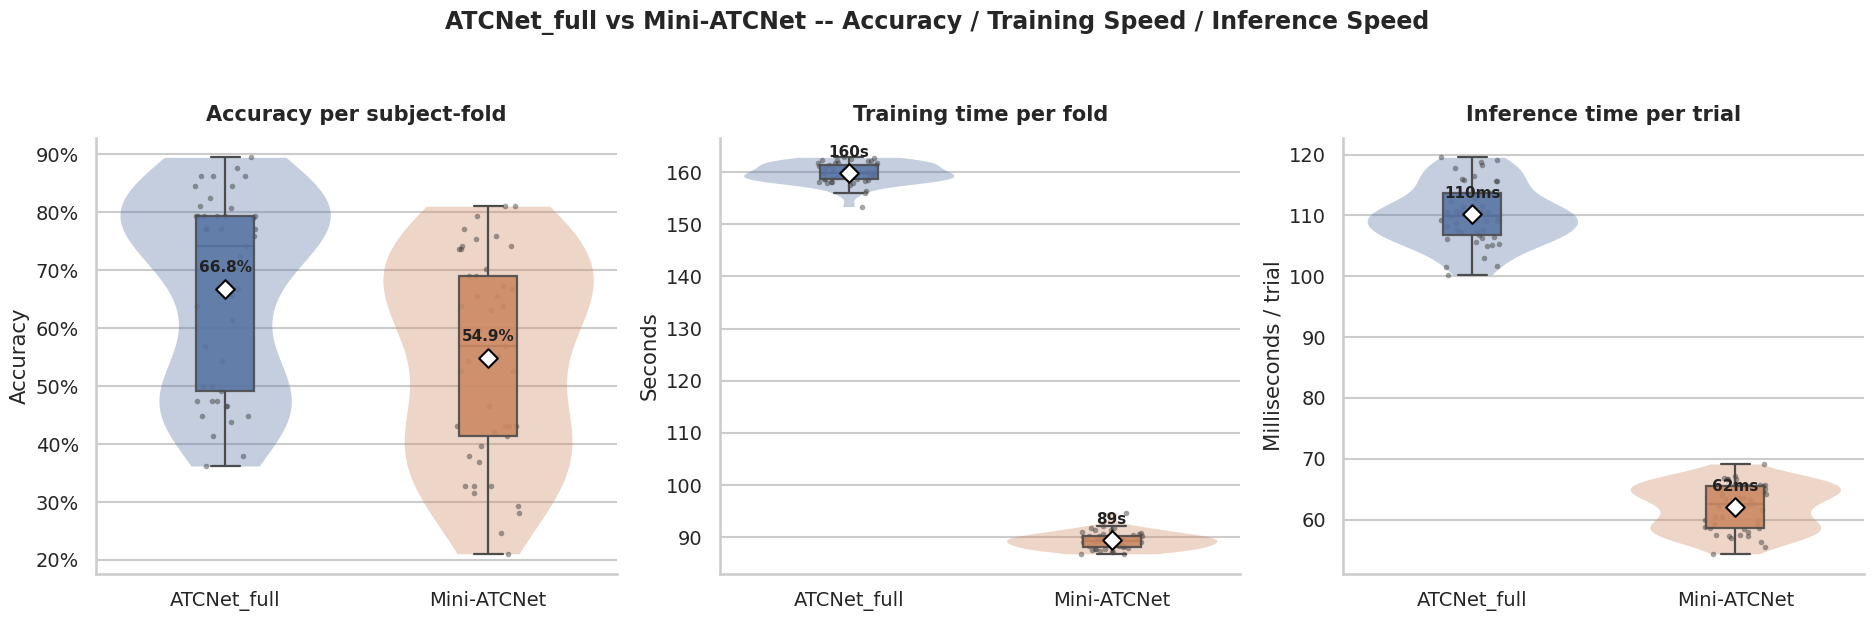

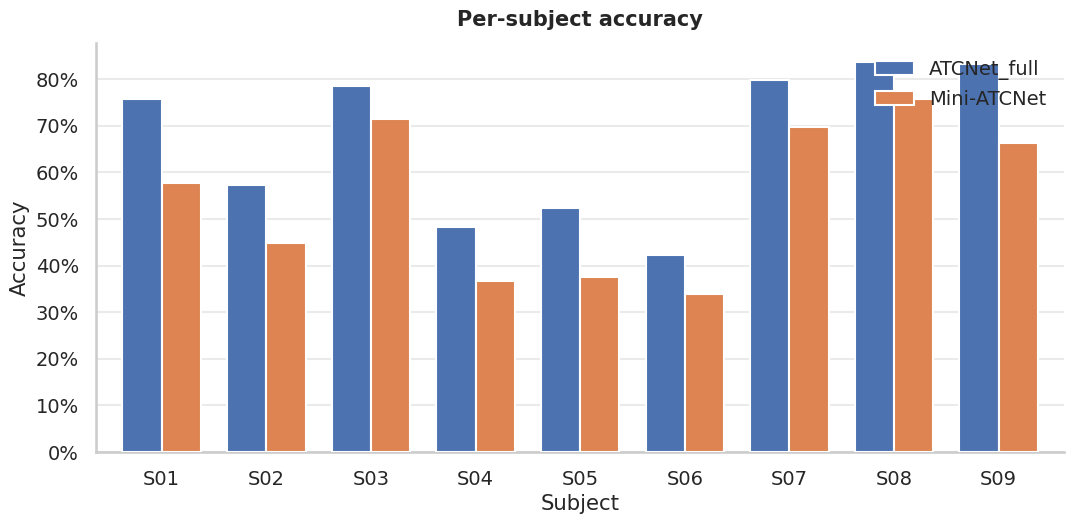

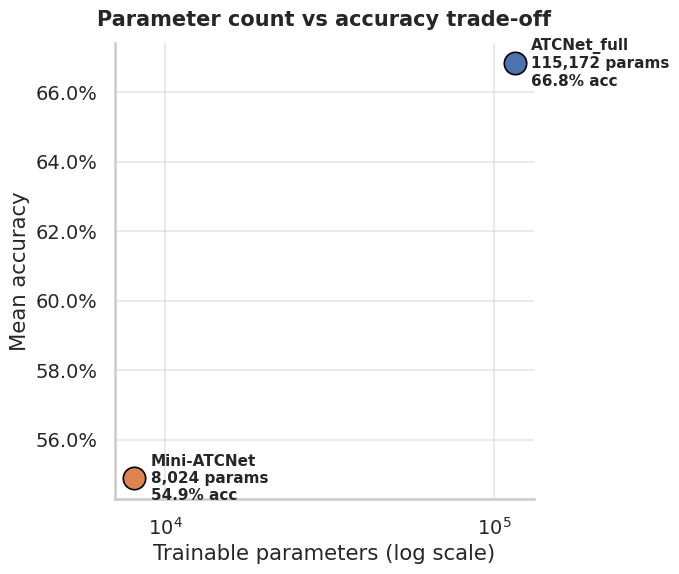


=== ATCNet_full classification report ===
              precision    recall  f1-score   support

        Left       0.61      0.73      0.67       648
       Right       0.65      0.70      0.68       648
        Foot       0.71      0.58      0.64       648
      Tongue       0.72      0.66      0.68       648

    accuracy                           0.67      2592
   macro avg       0.67      0.67      0.67      2592
weighted avg       0.67      0.67      0.67      2592


=== Mini-ATCNet classification report ===
              precision    recall  f1-score   support

        Left       0.51      0.62      0.56       648
       Right       0.55      0.59      0.57       648
        Foot       0.59      0.43      0.50       648
      Tongue       0.56      0.56      0.56       648

    accuracy                           0.55      2592
   macro avg       0.55      0.55      0.55      2592
weighted avg       0.55      0.55      0.55      2592



In [7]:
comparison = results_df.groupby('config')[
    ['accuracy', 'f1_macro', 'kappa', 'train_time_s', 'test_time_ms_per_trial', 'n_epochs']
].agg(['mean', 'std'])
print('=== Overall comparison (mean +/- std across all 45 subject-fold runs per config) ===')
print(comparison.round(4))

print(chr(10) + '=== Mode-collapse count per config (folds where >90pct of predictions were one class) ===')
print(results_df.groupby('config')['collapsed'].sum())

print('\n=== Parameter count vs accuracy trade-off ===')
for name in MODEL_CONFIGS:
    acc_mean = comparison.loc[name, ('accuracy', 'mean')]
    print(f'{name}: {param_counts[name]:,} params, {acc_mean:.1%} mean accuracy, '
          f'{acc_mean / param_counts[name] * 1e6:.3f} accuracy-points per million params')

print('\n=== Per-subject accuracy by config ===')
per_subject_acc = results_df.pivot_table(index='subject', columns='config', values='accuracy', aggfunc='mean')
print(per_subject_acc.round(4))

# -------------------- plotting (polished) --------------------
sns.set_theme(style='whitegrid', context='talk', font_scale=0.85)
PALETTE = {'ATCNet_full': '#4C72B0', 'Mini-ATCNet': '#DD8452'}
CONFIG_ORDER = list(MODEL_CONFIGS.keys())

def _annotate_means(ax, data, col, fmt):
    means = data.groupby('config')[col].mean()
    for i, cfg in enumerate(CONFIG_ORDER):
        m = means[cfg]
        ax.scatter(i, m, marker='D', s=90, facecolor='white', edgecolor='black', linewidth=1.5, zorder=5)
        ax.annotate(fmt.format(m), (i, m), xytext=(0, 12), textcoords='offset points',
                    ha='center', fontsize=11, fontweight='bold', color='#222222')

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
metric_specs = [
    ('accuracy', 'Accuracy', 'Accuracy per subject-fold', '{:.1%}'),
    ('train_time_s', 'Seconds', 'Training time per fold', '{:.0f}s'),
    ('test_time_ms_per_trial', 'Milliseconds / trial', 'Inference time per trial', '{:.0f}ms'),
]
for ax, (col, ylabel, title, fmt) in zip(axes, metric_specs):
    sns.violinplot(data=results_df, x='config', y=col, order=CONFIG_ORDER, hue='config',
                    palette=PALETTE, legend=False, ax=ax, inner=None, cut=0, alpha=0.35, linewidth=0)
    sns.boxplot(data=results_df, x='config', y=col, order=CONFIG_ORDER, hue='config',
                palette=PALETTE, legend=False, ax=ax, width=0.22, fliersize=0, linewidth=1.6,
                boxprops=dict(alpha=0.9, zorder=3), whiskerprops=dict(zorder=3), capprops=dict(zorder=3))
    sns.stripplot(data=results_df, x='config', y=col, order=CONFIG_ORDER, ax=ax,
                  color='#333333', alpha=0.45, size=4, jitter=0.12, zorder=2)
    _annotate_means(ax, results_df, col, fmt)
    ax.set_title(title, fontsize=15, fontweight='bold', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    if col == 'accuracy':
        ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))

sns.despine(fig=fig)
fig.suptitle('ATCNet_full vs Mini-ATCNet -- Accuracy / Training Speed / Inference Speed', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('atcnet_vs_mini_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

# per-subject grouped bar chart -- makes the 'is one config just uniformly better' question visual at a glance
fig2, ax2 = plt.subplots(figsize=(11, 5.5))
per_subject_acc[CONFIG_ORDER].plot(kind='bar', ax=ax2, color=[PALETTE[c] for c in CONFIG_ORDER], width=0.75, zorder=3)
ax2.set_title('Per-subject accuracy', fontsize=15, fontweight='bold', pad=12)
ax2.set_xlabel('Subject')
ax2.set_ylabel('Accuracy')
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))
ax2.set_xticklabels([f'S{int(s):02d}' for s in per_subject_acc.index], rotation=0)
ax2.legend(title='', frameon=False, loc='upper right')
ax2.grid(axis='y', alpha=0.4)
ax2.grid(axis='x', visible=False)
sns.despine(ax=ax2)
plt.tight_layout()
plt.savefig('atcnet_vs_mini_per_subject.png', dpi=160, bbox_inches='tight')
plt.show()

# parameter-count vs accuracy efficiency scatter -- the 'accuracy per million params' trade-off, visually
fig3, ax3 = plt.subplots(figsize=(7, 6))
for cfg in CONFIG_ORDER:
    acc_mean = comparison.loc[cfg, ('accuracy', 'mean')]
    ax3.scatter(param_counts[cfg], acc_mean, s=260, color=PALETTE[cfg], edgecolor='black', linewidth=1.2, zorder=3)
    ax3.annotate(f'{cfg}\n{param_counts[cfg]:,} params\n{acc_mean:.1%} acc',
                 (param_counts[cfg], acc_mean), xytext=(12, 0), textcoords='offset points',
                 fontsize=11, va='center', fontweight='bold')
ax3.set_xscale('log')
ax3.set_xlabel('Trainable parameters (log scale)')
ax3.set_ylabel('Mean accuracy')
ax3.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))
ax3.set_title('Parameter count vs accuracy trade-off', fontsize=15, fontweight='bold', pad=12)
ax3.grid(alpha=0.4)
sns.despine(ax=ax3)
plt.tight_layout()
plt.savefig('atcnet_vs_mini_efficiency.png', dpi=160, bbox_inches='tight')
plt.show()

for config_name in MODEL_CONFIGS:
    sub_results = [r for r in all_results if r['config'] == config_name]
    y_true_all = np.concatenate([r['y_true'] for r in sub_results])
    y_pred_all = np.concatenate([r['y_pred'] for r in sub_results])
    print(f'\n=== {config_name} classification report ===')
    print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES))


## 6. How to read and report this comparison

- **Accuracy delta**: whatever the boxplots and per-subject table above show is the number to cite — if
  Mini-ATCNet trails ATCNet_full, quantify by how much (percentage points), not just "similar" or "worse."
- **Training time**: measured as full wall-clock time for `model.fit` including early stopping, so it already
  reflects that a smaller model can afford more epochs in the same time budget, not just faster per-epoch
  steps. Report both mean training time and how many epochs each configuration actually ran before
  early-stopping triggered (`n_epochs` column).
- **Inference time per trial** is the number that matters most for the assistive-BCI deployment framing —
  this is closer to the latency a real-time control loop would see per decision. Compare this figure, not
  just parameter count, when arguing Mini-ATCNet is the more deployment-appropriate choice.
- **Honest framing for a CV/interview**: state the measured trade-off directly, e.g. "Mini-ATCNet used
  approximately X% of ATCNet's parameters and ran inference in Y% of the time, at a cost of Z accuracy
  points" — a quantified trade-off is a stronger, more credible claim than either "faster" or "smaller" alone.
- **Open item**: this notebook still evaluates both configs with subject-dependent 5-fold CV within the
  training session, not ATCNet's original train-on-session-1/test-on-session-2 protocol — the `E` session
  files in this dataset don't carry true labels.

## 7. Saved artifacts and how to reload them

Each config saves to its own subfolder: `/kaggle/working/saved_models_atcnet_compare/{config_name}/S{subject}_fold{fold}_model.keras`
and the matching `_scaler.pkl`.

In [8]:
def load_fold_artifacts(subject, fold, config_name):
    save_dir = os.path.join(SAVE_DIR_ROOT, config_name)
    fold_tag = f'S{subject:02d}_fold{fold:02d}'
    model = tf.keras.models.load_model(os.path.join(save_dir, f'{fold_tag}_model.keras'))
    with open(os.path.join(save_dir, f'{fold_tag}_scaler.pkl'), 'rb') as f:
        scaler = pickle.load(f)
    return model, scaler


def predict_raw_trials(X_raw, subject, fold, config_name):
    """X_raw: (n_trials, n_channels, n_samples), band-pass filtered the same way as subject_data."""
    model, scaler = load_fold_artifacts(subject, fold, config_name)
    X_flat = scaler.transform(X_raw.reshape(X_raw.shape[0], -1)).reshape(X_raw.shape)
    X_in = X_flat[..., np.newaxis].astype('float32')
    return np.argmax(model.predict(X_in, verbose=0), axis=1)


# example: reload subject 1's fold 1 model from the Mini-ATCNet config
# example_model, example_scaler = load_fold_artifacts(subject=1, fold=1, config_name='Mini-ATCNet')
